In [167]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm

# TODO:
# Use two matrices for VQ-VAE model lossy data compression
# Divide data into 4 x 4 batches
# Find embeddings using ADCS 4 x 4 batches
# scale patches into smaller scales

# Task:
# 1 patch'a - 1 pavyzdinis. Galima reguliuoti.
# Pasiimti viena event'a, nurodyti 8 x 8 patch'us ir kiekviena kvantuoti.


In [168]:
SELECTED_EVENTS = 1
EVENT_COUNT = 12
BATCH_SIZE = 8
PATCH_SIZE = 8

In [169]:
# Utillities
def show_image(events: np.array) -> None:
    image_plot = events.to_images()[0][1]
    plt.imshow(image_plot, cmap='gist_yarg', origin='lower')
    plt.show()
    
def plot_patch(patch: np.array) -> None:
    plt.imshow(patch, cmap='gist_yarg', origin='lower')
    plt.show()
    
def _get_ssim_value(image1: np.array, image2: np.array) -> float:
    image2_min_value = image2.min()
    image2_max_value = image2.max()
    
    ssmi_value = ssim(
        image1, 
        image2, 
        data_range=image2_max_value - image2_min_value,
        win_size=3
    )
    
    return ssmi_value

def _tensor_to_numpy(values: torch.Tensor) -> np.array:
    return values.cpu().detach().numpy()

def plot_metric_results(
    y_values: list[float], 
    epochs: int, 
    y_title: str, 
    title: str,
    x_label: str
) -> None:
    print(title + " values over epochs")
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, y_values)
    plt.xlabel(x_label)
    plt.ylabel(y_title)
    plt.legend()
    plt.title(title)
    plt.show()
    
def collate_fn(batch: torch.tensor):
    tensors = [
        torch.tensor(x).reshape(
            PATCH_SIZE, 
            PATCH_SIZE
        ).unsqueeze(1).unsqueeze(1).permute(1, 2, 0, 3)
        for x in batch
    ]
    return tensors

def _get_vq_loss(recon_x, x, vq_loss):
    recon_loss = F.mse_loss(recon_x, x)
    return recon_loss + vq_loss

In [170]:
# Moduliai ir ju savybes aprasomos pixel_modules json'uose
pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:04<00:00, 214.77it/s]


In [171]:
# Params
batch_size = 64
learning_rate = 1e-3
# num_epochs = 80
num_epochs = 60
channels = 1
latent_dim = 12
num_embeddings = 64  # Number of vectors in the codebook
beta = 0.5 # Beta, the commitment loss weight for moving vectors closer to the cendroid
num_residual_hiddens = 3
num_residual_layers = 2


decay = 0.75
vq_epsilon = 1e-5

# TODO: 4 x 4 compress to 2 x 2

In [172]:
# Selecting GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Applying seed for reproducability
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

device

device(type='cuda')

In [173]:
event_train = events_train[:SELECTED_EVENTS][0]


In [174]:
events_train_display = iter(events_train)

In [175]:
event_train_patches = event_hits_to_patches(event_train, patch_size=PATCH_SIZE)
event_train_patches_adcs = event_train_patches.as_array()
event_train_patches_adcs.shape

(15857, 64)

In [176]:
event_train_patches_adcs[0].shape

(64,)

In [177]:
len(event_train_patches_adcs)

15857

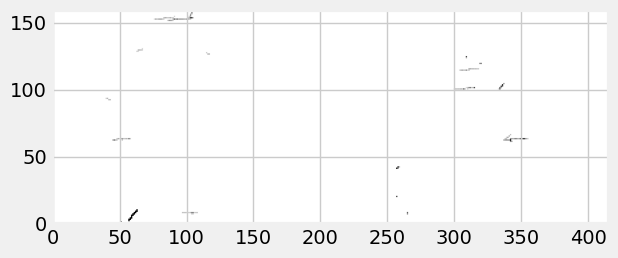

In [178]:
# plt.figure(figsize=(12, 6))
show_image(event_train)

In [179]:
# X_patches_batches = torch.tensor(X_patches_batches).unsqueeze(1).float()
transform = transforms.Compose([
    transforms.ToTensor(),
])
train_loader = DataLoader(
    dataset=event_train_patches_adcs, 
    batch_size=batch_size, 
    collate_fn=collate_fn
)

In [180]:
data_sample = next(iter(train_loader))
data_sample[0].shape

torch.Size([1, 1, 8, 8])

In [181]:
len(train_loader)

248

In [182]:
class VQEmbedding(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, commitment_cost, decay, epsilon):
        super().__init__()

        self._num_embeddings = num_embeddings
        self._embedding_dim = embedding_dim

        self._embedding = nn.Embedding(self._num_embeddings, self._embedding_dim)
        self._embedding.weight.data.normal_()
        self._commitment_cost = commitment_cost

        self.register_buffer('_ema_cluster_size', torch.zeros(num_embeddings))
        self.register_buffer("_ema_w", self._embedding.weight.data.clone())
        
        self._decay = decay
        self._device = device
        self._epsilon = epsilon

    def forward(self, inputs):
        """
        Connects the module to some inputs.

        Args:
            inputs: Tensor, final dimension must be equal to embedding_dim. All other
                leading dimensions will be flattened and treated as a large batch.
        
        Returns:
            loss: Tensor containing the loss to optimize.
            quantize: Tensor containing the quantized version of the input.
            perplexity: Tensor containing the perplexity of the encodings.
            encodings: Tensor containing the discrete encodings, ie which element
                of the quantized space each input element was mapped to.
            distances
        """

        # Convert inputs from BCHW -> BHWC
        # inputs = inputs.permute(1, 0, 2, 3).contiguous()
        input_shape = inputs.shape
        
        # Flatten input
        flat_input = inputs.view(-1, self._embedding_dim)
        
        # Compute distances between encoded audio frames and embedding vectors
        distances = (torch.sum(flat_input**2, dim=1, keepdim=True) 
                    + torch.sum(self._embedding.weight**2, dim=1)
                    - 2 * torch.matmul(flat_input, self._embedding.weight.t()))

        """
        encoding_indices: Tensor containing the discrete encoding indices, ie
        which element of the quantized space each input element was mapped to.
        """
        encoding_indices = torch.argmin(distances, dim=1).unsqueeze(1)
        encodings = torch.zeros(encoding_indices.shape[0], self._num_embeddings, dtype=torch.float).to(self._device)
        encodings.scatter_(1, encoding_indices, 1)


        # Sample nearest embedding
        # Use EMA to update the embedding vectors
        if self.training:
            with torch.no_grad():
                # EMA cluster size
                self._ema_cluster_size.mul_(self._decay).add_(
                    encodings.sum(0), alpha=1 - self._decay
                )

                # EMA embedding weights
                dw = torch.matmul(encodings.t(), flat_input)  # [K, C]
                self._ema_w.mul_(self._decay).add_(dw, alpha=1 - self._decay)

                # Laplace smoothing
                n = self._ema_cluster_size.sum()
                smoothed_cluster_size = (
                    (self._ema_cluster_size + self._epsilon)
                    / (n + self._num_embeddings * self._epsilon)
                    * n
                )

                self._embedding.weight.data.copy_(
                    self._ema_w / smoothed_cluster_size.unsqueeze(1)
                )

        
        avg_probs = torch.mean(encodings, dim=0)
        # Quantize and unflatten
        quantized = torch.matmul(encodings, self._embedding.weight).view(input_shape)
        # TODO: Check if the more readable self._embedding.weight.index_select(dim=1, index=encoding_indices) works better
        # Loss
        e_latent_loss = torch.mean((quantized.detach() - inputs)**2)
        commitment_loss = self._commitment_cost * e_latent_loss        
        quantized = inputs + (quantized - inputs).detach()
        perplexity = torch.exp(-torch.sum(avg_probs * torch.log(avg_probs + 1e-10)))
        """
        The perplexity a useful value to track during training.
        It indicates how many codes are 'active' on average.
        """

        quantized = quantized.view(input_shape)  # [B, H, W, C]
        # quantized = quantized.permute(0, 3, 2, 1).contiguous()  # [B, C, H, W]
        # Convert quantized from BHWC -> BCHW
        return (
            quantized, 
            commitment_loss, 
            perplexity,
            encodings
        )

In [183]:
class Residual(nn.Module):
    """
    Residual Convolutional Layer
    """

    def __init__(self, in_channels, num_hiddens, num_residual_hiddens):
        """
        initialize residual CNN layer

        :param in_channels number: Number of input channels
        :param num_hiddens number: Number of hidden channels
        :param num_residual_hiddens number: Number of residual hiddens
        """
        super(Residual, self).__init__()
        self._block = nn.Sequential(
            nn.ReLU(True),
            # C: 3 -> residual hidden
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=num_residual_hiddens,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),
            nn.ReLU(True),
            # C: resiual hidden -> out_hidden
            nn.Conv2d(
                in_channels=num_residual_hiddens,
                out_channels=in_channels,
                kernel_size=1,
                stride=1,
                bias=False,
            ),
        )

    def forward(self, x):
        """
        Residual layer

        :param x numpy.ndarray: Input image
        """
        return x + self._block(x)  # residual output


class ResidualStack(nn.Module):
    """
    Residual Convolution Stack
    """

    def __init__(
        self, in_channels, num_hiddens, num_residual_layers, num_residual_hiddens
    ):
        """
        initialize residual stack

        :param in_channels number: Number of input channels
        :param num_hiddens number: Number of hidden channels
        :param num_residual_layers number: Number of residual layers in stack
        :param num_residual_hiddens number: Number of hidden residual channels
        """
        super(ResidualStack, self).__init__()
        self._num_residual_layers = num_residual_layers
        self._layers = nn.ModuleList(
            [
                Residual(in_channels, num_hiddens, num_residual_hiddens)
                for _ in range(self._num_residual_layers)
            ]
        )

    def forward(self, x):
        """
        Apply residual stack

        :param x numpy.ndarray: Input image
        """
        # Apply all residual layers in stack
        for i in range(self._num_residual_layers):
            x = self._layers[i](x)
        return F.relu(x)

In [184]:

class VQVAE(nn.Module):
    def __init__(self, hidden_channels: int, kernel_size: int, debug: bool=False):
        super(VQVAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size, stride=1),
            nn.ReLU(),
            nn.Conv2d(hidden_channels, latent_dim, kernel_size=kernel_size),
            nn.ReLU()
        )
        self.debug = debug

        # Vector Quantization
        self.vq_layer = VQEmbedding(
            num_embeddings, 
            latent_dim, 
            beta, 
            decay=decay, 
            epsilon=vq_epsilon
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels, kernel_size=kernel_size),
            nn.ReLU(),
            nn.ConvTranspose2d(hidden_channels, channels, kernel_size=kernel_size, stride=1),
            nn.ReLU(),
        )
        self.debug = debug

    def forward(self, x):
        z_e = self.encoder(x)        
        
        # print(f"Compressed shape: {z_e.shape}")
        
        z_q, vq_loss, perplexity, encodings = self.vq_layer(z_e)
        
        x_recon = self.decoder(z_q)
        
        encodings_size_bits = (encodings.element_size() * encodings.numel()) * 8
        x_bits =  (x.element_size() * x.numel()) * 8
        
        compression_size = encodings_size_bits / x_bits
        
        return (
            x_recon, 
            vq_loss, 
            perplexity, 
            compression_size
        )
# class VQVAE(nn.Module):
#     def __init__(self, hidden_channels: int, kernel_size: int, debug: bool=False):
#         super(VQVAE, self).__init__()
#         self.encoder = nn.Sequential(
#             nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size, stride=1),
#             nn.ReLU(),
#             nn.Conv2d(hidden_channels, latent_dim, kernel_size=kernel_size),
#             nn.ReLU(),
#             # nn.Conv2d(6, latent_dim, kernel_size=1),
#             # nn.ReLU()
#             # nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
#             # nn.Conv2d(32, 64, kernel_size=2, stride=1, padding=1),
          
#             # nn.LeakyReLU(0.1),
#             # nn.Conv2d(64, latent_dim, kernel_size=2),
#             # ResidualStack(
#             #     in_channels=latent_dim,channels
#             #     num_hiddens=latent_dim,
#             #     num_residual_layers=num_residual_layers,
#             #     num_residual_hiddens=num_residual_hiddens,
#             # )
#         )
#         self.debug = debug

#         # Vector Quantization
#         self.vq_layer = VQEmbedding(
#             num_embeddings, 
#             latent_dim, 
#             beta, 
#             decay=decay, 
#             epsilon=vq_epsilon
#         )

#         # Decoder
#         self.decoder = nn.Sequential(
#             # ResidualStack(
#             #     in_channels=latent_dim,
#             #     num_hiddens=latent_dim,
#             #     num_residual_layers=num_residual_layers,
#             #     num_residual_hiddens=num_residual_hiddens,
#             # ),
#             nn.ConvTranspose2d(latent_dim, hidden_channels, kernel_size=kernel_size),
#             nn.ReLU(),
#             nn.ConvTranspose2d(hidden_channels, channels, kernel_size=kernel_size, stride=1),
#             nn.ReLU(),
#             # nn.ConvTranspose2d(3, channels, kernel_size=2, stride=1),
#             # nn.ReLU(),
#             # nn.ConvTranspose2d(6, channels, kernel_size=2, stride=1),
#             # nn.ReLU(),
#             # nn.ConvTranspose2d(64, 32, kernel_size=2, stride=1, padding=1),
#             # nn.LeakyReLU(0.1),
#             # nn.ConvTranspose2d(32, 16, kernel_size=3, stride=1, padding=1),
#             # nn.LeakyReLU(0.1),
#             # nn.ConvTranspose2d(16, channels, kernel_size=2, stride=1, padding=1),
#             # nn.Sigmoid() 
#         )
#         self.debug = debug

#     def forward(self, x):
#         z_e = self.encoder(x)        
        
#         # print(f"Compressed shape: {z_e.shape}")
        
#         z_q, vq_loss, perplexity, encodings = self.vq_layer(z_e)
#         used_codes = torch.sum(encodings, dim=0) > 0
#         num_used = used_codes.sum()
        
#         if self.debug:
#             print(f"Compressed shape: {z_q.shape}")
#             print(f"Codebooks: {num_used}")
        
        
#         x_recon = self.decoder(z_q)
#         return x_recon, vq_loss, perplexity

In [185]:
model = VQVAE(
    hidden_channels = 3,
    kernel_size = 2
).to(device)
optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

In [186]:
# # debug
# model.train()
# event_patch = next(iter(train_loader))
# event_patch_train = event_patch[0].float().to(device)
# model.encoder(event_patch_train).shape



Epoch 1/60: 100%|██████████| 248/248 [00:00<00:00, 520.91it/s, Loss=411]    


Before compression
Before: (8, 8)


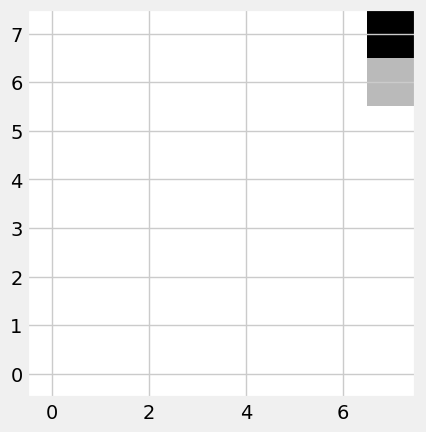

After: (8, 8)
After compression


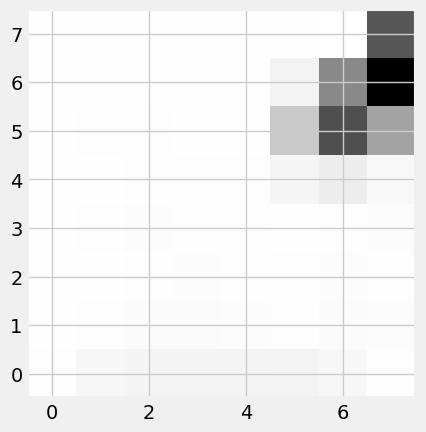

Epoch [1/60] Average Loss: 376.1488


Epoch 2/60: 100%|██████████| 248/248 [00:00<00:00, 460.39it/s, Loss=371]    


Epoch [2/60] Average Loss: 257.2019


Epoch 3/60: 100%|██████████| 248/248 [00:00<00:00, 497.28it/s, Loss=313]    


Epoch [3/60] Average Loss: 225.1379


...

Epoch [9/60] Average Loss: 151.0460


Epoch 10/60: 100%|██████████| 248/248 [00:00<00:00, 516.67it/s, Loss=104]    


Epoch [10/60] Average Loss: 138.1850


Epoch 11/60: 100%|██████████| 248/248 [00:00<00:00, 540.40it/s, Loss=107]   


Before compression
Before: (8, 8)


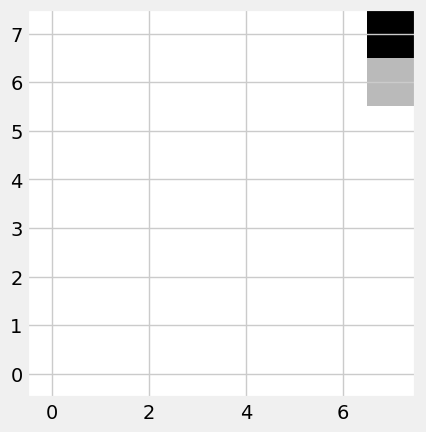

After: (8, 8)
After compression


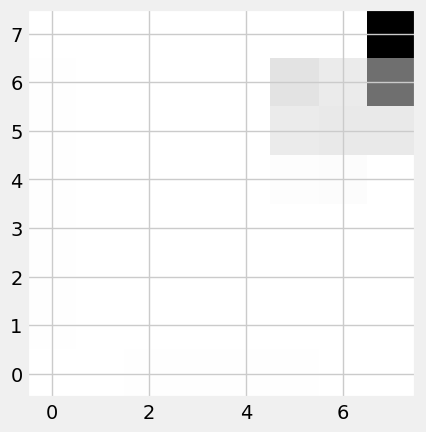

Epoch [11/60] Average Loss: 134.7114


Epoch 12/60: 100%|██████████| 248/248 [00:00<00:00, 459.25it/s, Loss=100] 


Epoch [12/60] Average Loss: 129.4205


Epoch 13/60: 100%|██████████| 248/248 [00:00<00:00, 441.04it/s, Loss=85.8]


Epoch [13/60] Average Loss: 123.9355


...

Epoch [19/60] Average Loss: 105.0373


Epoch 20/60: 100%|██████████| 248/248 [00:00<00:00, 531.42it/s, Loss=91.2]


Epoch [20/60] Average Loss: 96.0706


Epoch 21/60: 100%|██████████| 248/248 [00:00<00:00, 498.81it/s, Loss=98]  


Before compression
Before: (8, 8)


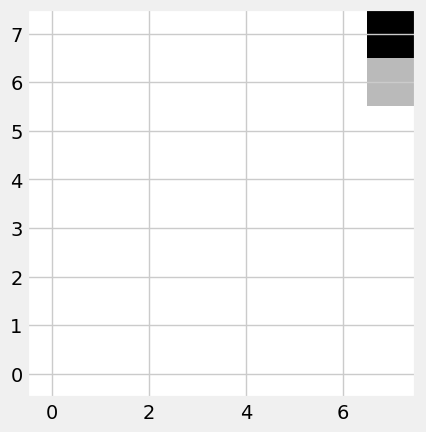

After: (8, 8)
After compression


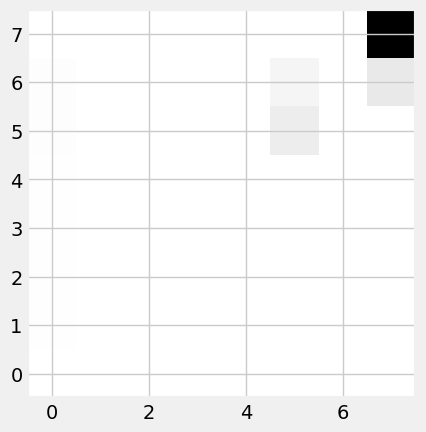

Epoch [21/60] Average Loss: 100.0890


Epoch 22/60: 100%|██████████| 248/248 [00:00<00:00, 568.86it/s, Loss=141] 


Epoch [22/60] Average Loss: 98.1309


Epoch 23/60: 100%|██████████| 248/248 [00:00<00:00, 511.23it/s, Loss=133]  


Epoch [23/60] Average Loss: 98.5953


...

Epoch [29/60] Average Loss: 87.1433


Epoch 30/60: 100%|██████████| 248/248 [00:00<00:00, 440.88it/s, Loss=110] 


Epoch [30/60] Average Loss: 92.6000


Epoch 31/60: 100%|██████████| 248/248 [00:00<00:00, 509.38it/s, Loss=100] 


Before compression
Before: (8, 8)


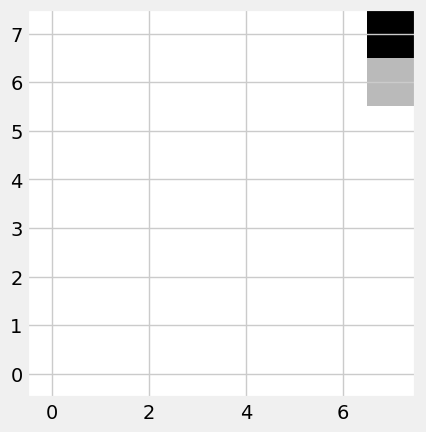

After: (8, 8)
After compression


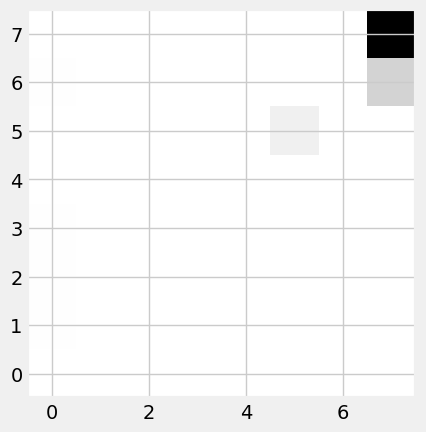

Epoch [31/60] Average Loss: 89.4867


Epoch 32/60: 100%|██████████| 248/248 [00:00<00:00, 523.22it/s, Loss=102] 


Epoch [32/60] Average Loss: 85.0260


Epoch 33/60: 100%|██████████| 248/248 [00:00<00:00, 517.78it/s, Loss=92.9]


Epoch [33/60] Average Loss: 87.8305


...

Epoch [39/60] Average Loss: 84.7068


Epoch 40/60: 100%|██████████| 248/248 [00:00<00:00, 459.66it/s, Loss=89.2]


Epoch [40/60] Average Loss: 81.5676


Epoch 41/60: 100%|██████████| 248/248 [00:00<00:00, 473.14it/s, Loss=94]   


Before compression
Before: (8, 8)


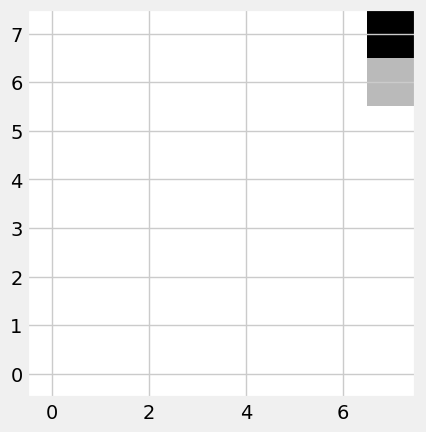

After: (8, 8)
After compression


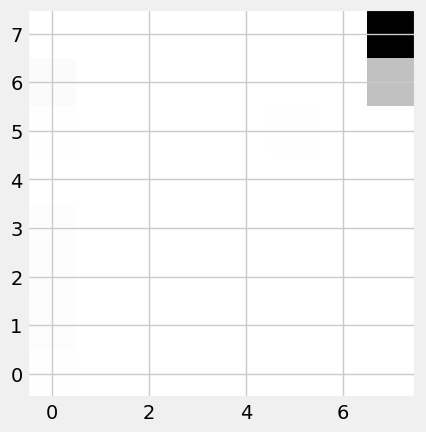

Epoch [41/60] Average Loss: 78.8919


Epoch 42/60: 100%|██████████| 248/248 [00:00<00:00, 476.02it/s, Loss=111] 


Epoch [42/60] Average Loss: 80.7068


Epoch 43/60: 100%|██████████| 248/248 [00:00<00:00, 520.98it/s, Loss=94.2] 


Epoch [43/60] Average Loss: 76.1399


...

Epoch [49/60] Average Loss: 81.6111


Epoch 50/60: 100%|██████████| 248/248 [00:00<00:00, 434.26it/s, Loss=103]  


Epoch [50/60] Average Loss: 79.2759


Epoch 51/60: 100%|██████████| 248/248 [00:00<00:00, 669.25it/s, Loss=84.3] 


Before compression
Before: (8, 8)


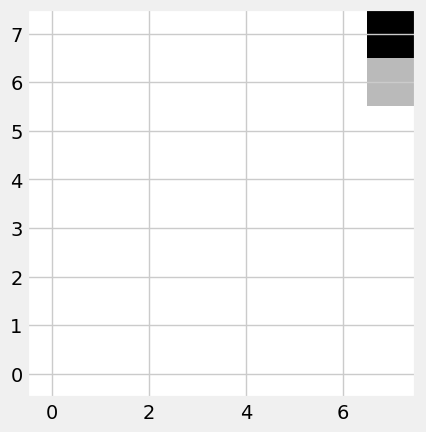

After: (8, 8)
After compression


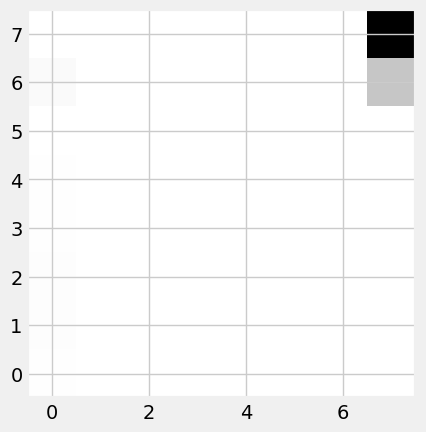

Epoch [51/60] Average Loss: 78.5991


Epoch 52/60: 100%|██████████| 248/248 [00:00<00:00, 771.40it/s, Loss=81.3]


Epoch [52/60] Average Loss: 78.4970


Epoch 53/60: 100%|██████████| 248/248 [00:00<00:00, 755.88it/s, Loss=75.4] 


Epoch [53/60] Average Loss: 76.8426


...

Epoch [58/60] Average Loss: 76.9991


Epoch 59/60: 100%|██████████| 248/248 [00:00<00:00, 786.88it/s, Loss=84.1] 


Epoch [59/60] Average Loss: 74.9822


Epoch 60/60: 100%|██████████| 248/248 [00:00<00:00, 809.47it/s, Loss=97.2]


Epoch [60/60] Average Loss: 72.6597


In [187]:
# loss
average_loss_values = []

# ssim
ssim_values = []

# perplexity
perplexity_values = []

epoch_values = list(range(num_epochs))

for epoch in epoch_values:
    model.train()
    train_loss = 0

    # Use tqdm for the progress bar
    progress_bar = tqdm(
        enumerate(train_loader), 
        total=len(train_loader), 
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    for batch_idx, patch_adcs in progress_bar:
        X_adcs = patch_adcs[0]
        X_adcs = X_adcs.float()
        X_adcs = X_adcs.to(device)

        optimizer.zero_grad()
        
        recon_patch, vq_loss, perplexity, _, = model(
            X_adcs
        )
        recon_patch = recon_patch.float()
    
        loss = _get_vq_loss(recon_patch, X_adcs, vq_loss)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss': loss.item()})
    
    if epoch % 10 == 0:
        with torch.no_grad():            
            # selecting events before reconstruction
            print("Before compression")
            patch_original = _tensor_to_numpy(
                X_adcs.squeeze(1).view((PATCH_SIZE, PATCH_SIZE))
            )
            recon_patch_np = _tensor_to_numpy(
                recon_patch.squeeze(1).view((PATCH_SIZE, PATCH_SIZE))
            )
            
            print(f"Before: {patch_original.shape}")
            
            plot_patch(patch_original)
            
            (
                recon_patch, 
                _, 
                perplexity, 
                compression_ratio,
            ) = model(X_adcs)
            
            print(f"After: {recon_patch_np.shape}")
            print("After compression")
            plot_patch(recon_patch_np)
            
            # ssim_value = _get_ssim_value(
            #     patch_original,
            #     recon_patch_np
            # )
            # print(f"Perplexity: {perplexity}")
            # print(f"Compression ratio: {compression_ratio}")
            
        
    avg_loss = train_loss / len(train_loader)
    average_loss_values.append(avg_loss)
    
    print(f'Epoch [{epoch + 1}/{num_epochs}] Average Loss: {avg_loss:.4f}')

In [188]:
# TODO: Try fitting all patch'es to VQ-VAE, get calculated bits of patches and total hits per event.
# TODO: Calculate ratio before how many bits were used per patch and after compression how many bits were 
# used per patch 

In [189]:
# Test model with unseen data
events_test_patches_adcs = [
    event_hits_to_patches(event, PATCH_SIZE).as_array()
    for event in events_test[:SELECTED_EVENTS]
]

events_test_patches = [
    event_hits_to_patches(event, PATCH_SIZE)
    for event in events_test[:SELECTED_EVENTS]
]
print(f"Events test: {len(events_test_patches_adcs)}")
print(f"Event patches: {len(events_test_patches[0])}")


Events test: 1
Event patches: 8452


In [190]:
# Calculating bits per patch
events_test_patches_bits = {}
for event in events_test[:SELECTED_EVENTS]:
    event_bits = []
    for patch in event_hits_to_patches(event, PATCH_SIZE).as_array():
        bits_per_patch = patch.nbytes * 8
        event_bits.append(bits_per_patch)
    
    events_test_patches_bits[event.id_] = event_bits

In [191]:
X_test_patch = events_test_patches_adcs[0][0]
X_test = torch.tensor(X_test_patch).to(device).float()
X_test = X_test.reshape(
    PATCH_SIZE, 
    PATCH_SIZE
).unsqueeze(1).unsqueeze(1).permute(1, 2, 0, 3)

model.eval()

with torch.no_grad():
    model = VQVAE(
        hidden_channels = 3,
        kernel_size = 2    
    ).to(device)
    z = model.encoder(X_test)
    z, vq_loss, perplexity, encodings = model.vq_layer(z)
    print(f"Latent shape: {z.shape}")
    
    used_codes = torch.unique(encodings)
    num_used = used_codes.numel()
    
    print(f"Codebook unique encodings:{len(used_codes)}")
    print(encodings.shape)
    print(encodings.unique())
    
    codebook = model.vq_layer._embedding.weight
    codebook_size = codebook.element_size() * codebook.numel()
    
    print(f"Codebook size: {len(used_codes)}")
    

Latent shape: torch.Size([1, 12, 6, 6])
Codebook unique encodings:2
torch.Size([36, 64])
tensor([0., 1.], device='cuda:0')
Codebook size: 2


In [192]:
events_test[0].det_ids

array([303042564, 303042564, 303042564, ..., 353339396, 353339396,
       353339396], shape=(24791,), dtype=int32)

/tmp/ipykernel_2581622/1209458638.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Average reconstruction loss over epochs values over epochs


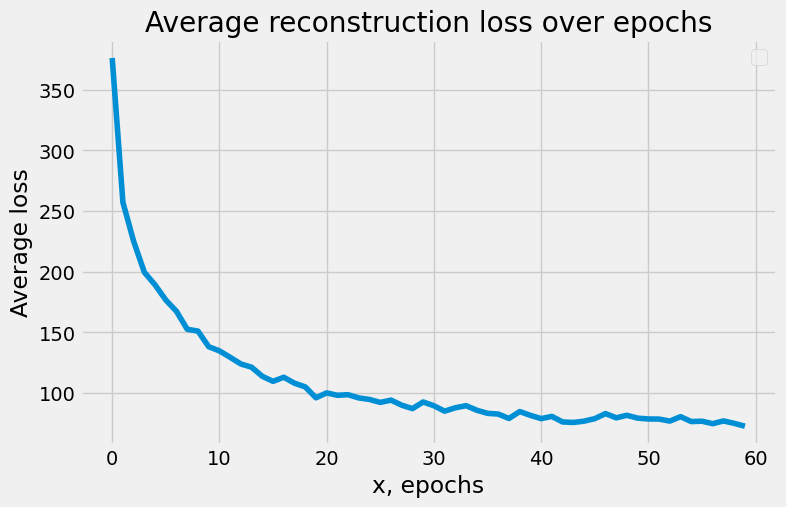

In [193]:
plot_metric_results(
    average_loss_values, 
    epoch_values, 
    "Average loss", 
    "Average reconstruction loss over epochs",
    "x, epochs"
)

In [194]:
torch.save(model.state_dict(), "vq_vae_pileup.pth")

In [195]:
# TODO: change debug for option change event_hit_test count
def _get_reshape_tensor(patch_flatten: np.array) -> torch.tensor:
    patch = patch_flatten.reshape(PATCH_SIZE, PATCH_SIZE)
    patch_tensor_ini = torch.tensor(patch)
    patch_tensor = patch_tensor_ini.unsqueeze(1).unsqueeze(1).transpose(0, 2)
    patch_tensor = patch_tensor.float()
    patch_tensor = patch_tensor.to(device)
    return patch_tensor

events_test_patches_tensors = []
for event_test_patches_adcs in events_test_patches_adcs:
    event_test_patches_tensors = list(map(_get_reshape_tensor, event_test_patches_adcs))
    event_test_patch_first = event_test_patches_tensors[0]
    print(f"DEBUG: first event shape: {event_test_patch_first.shape}")
    
    events_test_patches_tensors.append(event_test_patches_tensors)

DEBUG: first event shape: torch.Size([1, 1, 8, 8])


In [196]:
len(event_test_patches_tensors)

8452

Check patch compressed latent dimensions
Patch IDX = 1 compression results
Testing with unseen data
Patch compression statistics
Before: (8, 8)
After compression
After: (8, 8)
Patch compression ratio: 36.0
SSIM value = 0.18237335148607223


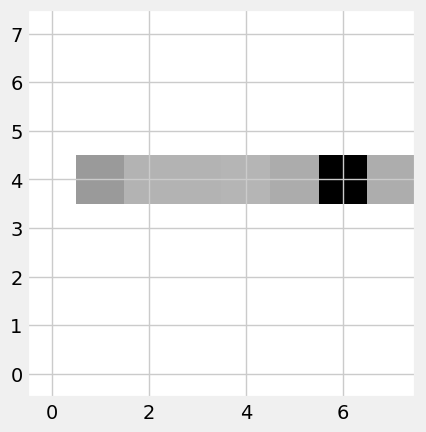

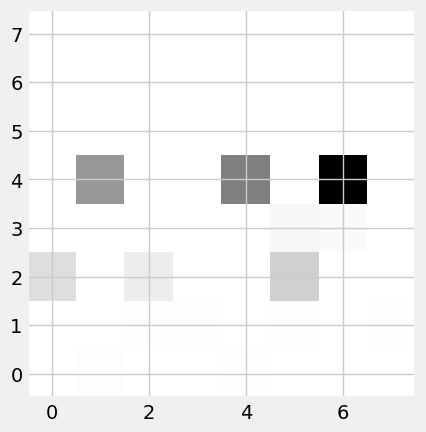

Patch IDX = 2 compression results
Testing with unseen data
Patch compression statistics
Before: (8, 8)
After compression
After: (8, 8)
Patch compression ratio: 36.0
SSIM value = 0.1449619354994372


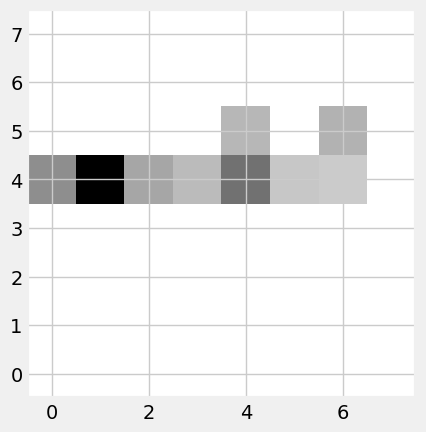

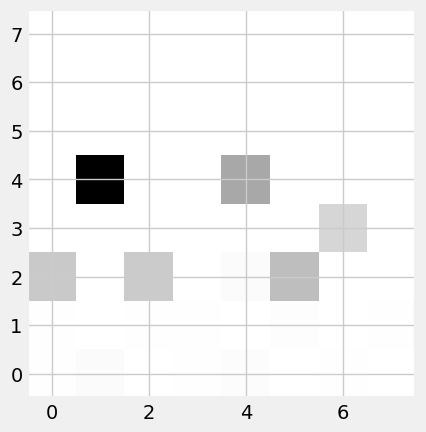

Patch IDX = 3 compression results
Testing with unseen data
Patch compression statistics
Before: (8, 8)
After compression
After: (8, 8)
Patch compression ratio: 36.0
SSIM value = 0.10362032938270874
Patch IDX = 4 compression results
Testing with unseen data
Patch compression statistics
Before: (8, 8)
After compression
After: (8, 8)
Patch compression ratio: 36.0
SSIM value = 0.00013299473885000325
Patch IDX = 5 compression results
Testing with unseen data
Patch compression statistics
Before: (8, 8)
After compression
After: (8, 8)
Patch compression ratio: 36.0
SSIM value = 0.327038768537834
Patch IDX = 6 compression results
Testing with unseen data
Patch compression statistics
Before: (8, 8)
After compression
After: (8, 8)
Patch compression ratio: 36.0
SSIM value = 0.4553229990341663
Patch IDX = 7 compression results
Testing with unseen data
Patch compression statistics
Before: (8, 8)
After compression
After: (8, 8)
Patch compression ratio: 36.0
SSIM value = 0.46357251785542847
Patch IDX 

/tmp/ipykernel_2581622/1209458638.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


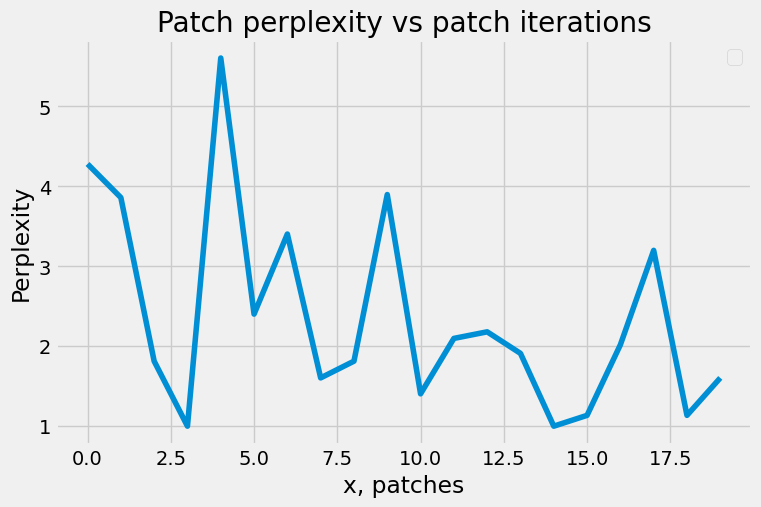

Showing ssim plot, event_id = 10785001
SSIM values vs patch iterations values over epochs


/tmp/ipykernel_2581622/1209458638.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


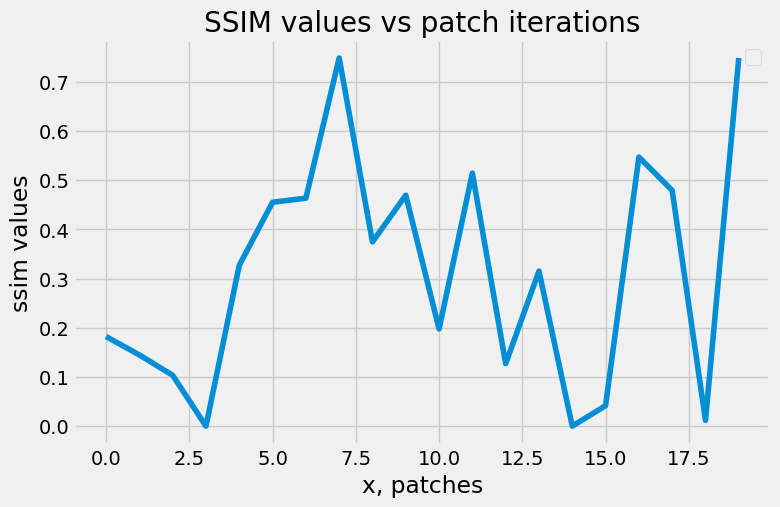

In [ ]:
# testing with new data
# DEBUG:
plot_patches_debug = 2 # selecting two patches for plotting. 
plotted_patches = 0
plot_elements = 20

model.load_state_dict(torch.load("vq_vae_pileup.pth"))
model = model.to(device)
model.eval()   

decompressed_events = [] 
events_test_patches_decoded_bits = {}
perplexity_values = []
codebook_sizes = []
ssim_values = []

print("Check patch compressed latent dimensions")
for (i, event_test_patch_tensors) in enumerate(events_test_patches_tensors):
    event_adcs_merged = []
    event_test_patches = events_test_patches[i]
    event_used_bits = []
    compression_ratio_values = []
    
    for (j, event_test_patch_tensor) in enumerate(event_test_patch_tensors):
        print(f"Patch IDX = {j + 1} compression results")

        event_patches_decompressed = None
        event_hits = None

        print("Testing with unseen data")

        with torch.no_grad():
            event_test_patch = _tensor_to_numpy(
                event_test_patch_tensor.squeeze(1).view(
                    (PATCH_SIZE, PATCH_SIZE)
                )
            )
            
            (
                recon_patch, 
                _, 
                perplexity, 
                compresstion_ratio
            ) = model(event_test_patch_tensor)
            
            # Reconstructed adcs
            recon_patch_np = _tensor_to_numpy(
                event_test_patch_tensor.squeeze(1).view(
                    (PATCH_SIZE, PATCH_SIZE)
                )
            )
            
            patch_original = _tensor_to_numpy(
                X_adcs.squeeze(1).view((PATCH_SIZE, PATCH_SIZE))
            )
            recon_patch_np = _tensor_to_numpy(
                recon_patch.squeeze(1).view((PATCH_SIZE, PATCH_SIZE))
            )
            ssim_value = _get_ssim_value(
                patch_original,
                recon_patch_np
            )
            
            
            print("Patch compression statistics")
            print(f"Before: {event_test_patch.shape}")
            print("After compression")
            print(f"After: {recon_patch_np.shape}")
            
            print(f"Patch compression ratio: {compression_ratio}")
            print(f"SSIM value = {ssim_value}")
            
            # Saving statistics
            perplexity_values.append(perplexity.item())
            ssim_values.append(
               ssim_value.item()
            )
            
            if plotted_patches < plot_patches_debug:
                plot_patch(event_test_patch)        
                plot_patch(recon_patch_np)
                plotted_patches += 1
            
            adcs_decoded = recon_patch_np.flatten()
            event_adcs_merged.append(adcs_decoded)
            
            event_used_bits.append(adcs_decoded.nbytes * 8)
    
    events_test_patches_decoded_bits[event_test_patches.event_id] = event_used_bits
         
    # # Make the first decompressed event
    event_patches_decompressed = PixelEventPatches(
        detector=pix_det,
        patch_size=PATCH_SIZE,
        event_id=event_test_patches.event_id,
        det_ids=event_test_patches.det_ids,
        rows=event_test_patches.rows,
        cols=event_test_patches.cols,
        adcs=np.concatenate(event_adcs_merged),
        occupancy=np.arange(64)
    )
    event_hits = event_patches_to_hits(
        event_patches_decompressed
    )
    decompressed_events.append(event_hits)
    
    print(f"Showing compression ratio plot, event_id = {event_hits.id_}")
        
    
    print(f"Showing perplexity plot, event_id = {event_hits.id_}")
    
    x_iterations = list(range(0, len(event_test_patch_tensors)))
    plot_metric_results(
        perplexity_values[:plot_elements], 
        x_iterations[:plot_elements], 
        "Perplexity", 
        "Patch perplexity vs patch iterations", 
        "x, patches"
    )
    
    
    print(f"Showing ssim plot, event_id = {event_hits.id_}")
    plot_metric_results(
        ssim_values[:plot_elements], 
        x_iterations[:plot_elements], 
        "ssim values", 
        "SSIM values vs patch iterations", 
        "x, patches"
    )
    
    # TODO: add interpretation compression ratio
    # TODO: add missmatch ratio

Event test before compression


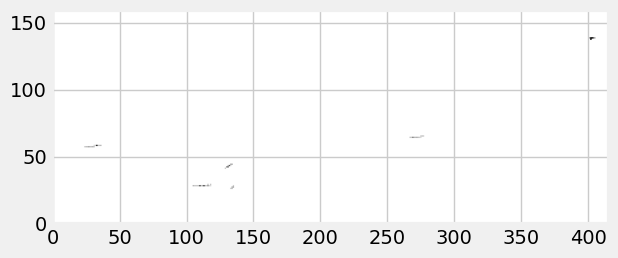

In [198]:
print("Event test before compression")
for event_test in events_test[:SELECTED_EVENTS]:
    show_image(event_test)

Event test after compression


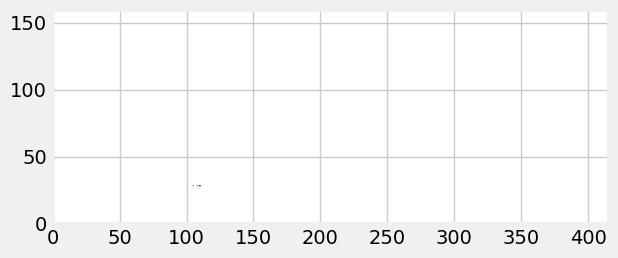

In [199]:
print("Event test after compression")
for event_test in decompressed_events[:SELECTED_EVENTS]:
    show_image(event_test)

<h2>Event compression statistics<h2>

In [200]:
# hit count in original events
n_hits_total = 0
for event_test in events_test[:SELECTED_EVENTS]:
    n_hits_total += len(event_test.hits)
    
print(f"Selected events have hits: {n_hits_total}")

Selected events have hits: 1558


In [208]:
# hit count in original events
n_hits_total_vq = 0
for decomp_event_test in decompressed_events[:SELECTED_EVENTS]:
    n_hits_total_vq += len(decomp_event_test.hits)
    
print(f"Decompressed events have hits: {n_hits_total_vq}")

Decompressed events have hits: 1


In [202]:
# len(decomp_event_test.adcs)

In [203]:
# # Analyzing difference ratio before and after

# events_before = events_test[:SELECTED_EVENTS]
# events_after = decompressed_events[:SELECTED_EVENTS]

# event_patchs_bits = []

# for i in range(SELECTED_EVENTS):
#     event_before = events_before[i]
#     event_before_bits = event_before.adcs.nbytes * 8
    
#     event_after = events_after[i]
#     event_after_bits = event_after.adcs.nbytes * 8
    
#     bits_difference = abs(event_before_bits - event_after_bits)
    
#     print(f"""
#           Event_id = {event_before.id_}, 
#           Bits difference (Before - after): {bits_difference}
#           Before: {event_before_bits} bits, after: {event_after_bits} bits
#           ----
#     """)
    
#     event_patches_bits_before = events_test_patches_bits[event_before.id_]
#     event_patches_bits_after = events_test_patches_decoded_bits[event_before.id_]
    
#     for (
#         event_patch_before, 
#         event_patch_after
#     ) in zip(
#         event_patches_bits_before, 
#         event_patches_bits_after
#     ):
#         print(event_patch_before, event_patch_after)

# # for (event_before, event_after) in list(zip(events_before, events_after)):
# #     # print(f"Event id: {event}")
    
# #     hits_bits_total_before = events_before.adcs.nbytes * 8
# #     hits_bits_total_after = events_after.adcs.nbytes * 8
# #     print(hits_bits_total_before)
    
    

In [204]:
# # calculate frechet inception distance
# def calculate_fid(act1, act2):
# 	# calculate mean and covariance statistics
# 	mu1, sigma1 = act1.mean(axis=0), cov(act1, rowvar=False)
# 	mu2, sigma2 = act2.mean(axis=0), cov(act2, rowvar=False)
# 	# calculate sum squared difference between means
# 	ssdiff = np.sum((mu1 - mu2)**2.0)
# 	# calculate sqrt of product between cov
# 	covmean = sqrtm(sigma1.dot(sigma2))
# 	# check and correct imaginary numbers from sqrt
# 	if iscomplexobj(covmean):
# 		covmean = covmean.real
# 	# calculate score
# 	fid = ssdiff + trace(sigma1 + sigma2 - 2.0 * covmean)
# 	return fid



In [205]:
# # Plot reconstructed particle events after decompression
# if event_hits:
#     show_image(event_hits)
    
#     # computing SSIM - Structural simalarity 
#     events_test_original = events_test[0].to_images()[0][1]
#     events_test_recons = event_hits.to_images()[0][1]
    
#     recon_min_value = events_test_recons.min()
#     recon_max_value = events_test_recons.max()
    
    
#     ssmi_value = ssim(
#         events_test_original, 
#         events_test_recons, 
#         data_range=recon_max_value - recon_min_value
#     )
    
#     # Compares how similar original and estinmated structures
#     print(f"SSIM (original vs new) = {ssmi_value}")
    
#     # Compares how similar to the image distribution
#     fid_value = calculate_fid(events_test_original, events_test_recons)
#     print(f"FID: {fid_value}")
    
    
# # TODO: check SSIM metric value, latent vectors

In [206]:
# plot_metric_results(
#     ssim_values, 
#     epoch_values[::10], 
#     "SSIM", 
#     "1 event patch SSIM value over epochs"
# )

In [207]:
# plot_metric_results(
#     perplexity_values, 
#     epoch_values[::10], 
#     "Perplexity", 
#     "Perplexity over epochs"
# )
# # Result: 1 try uses 7 codebooks at 10 epochs
# # Result: 2 try uses 8 codebooks at 10 epochs with decay = 0.75